In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from math import sqrt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.neural_network import MLPClassifier

In [ ]:
!pip install ipython-autotime
%load_ext autotime

time: 336 µs (started: 2021-01-09 12:12:14 +00:00)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
time: 1min 17s (started: 2021-01-09 12:12:14 +00:00)


In [ ]:
data = pd.read_csv("drive/MyDrive/Taiwan Hospice Project/final.csv",index_col=4)

time: 4.43 s (started: 2021-01-09 12:35:31 +00:00)


In [ ]:
data

,ACT,Angle,Spin,PATIENT
DateTime,,,,
2019-09-03 10:05:17,168.00,3.0,12.0,HP01
2019-09-03 10:05:27,191.00,4.0,11.0,HP01
2019-09-03 10:05:37,211.00,3.0,0.0,HP01
2019-09-03 10:05:47,87.00,2.0,3.0,HP01
2019-09-03 10:05:57,7.19,3.0,1.0,HP01
...,...,...,...,...
2020-08-19 20:18:38,1.81,15.0,0.0,HP45
2020-08-19 20:18:48,1.75,15.0,0.0,HP45
2020-08-19 20:18:58,1.56,15.0,0.0,HP45


time: 25.3 ms (started: 2021-01-09 12:35:57 +00:00)


In [ ]:
#Organize the data:
for i in range(1,46):
  if(i<10):
    name = 'HP0'+ str(i)
  else:
    name = 'HP'+ str(i)
  data.loc[data.PATIENT == name, 'dead'] = 0

time: 9.01 s (started: 2021-01-09 12:35:57 +00:00)


In [ ]:
dead_patients= ['06','07','08','11','12','14','17','20','21','22','23','25','29','32','35','37','40','42','45']
for i in dead_patients:
  name = 'HP'+i
  data.loc[data.PATIENT == name, 'dead'] = 1

time: 3.75 s (started: 2021-01-09 12:36:06 +00:00)


In [ ]:
data

,ACT,Angle,Spin,PATIENT,dead
DateTime,,,,,
2019-09-03 10:05:17,168.00,3.0,12.0,HP01,0.0
2019-09-03 10:05:27,191.00,4.0,11.0,HP01,0.0
2019-09-03 10:05:37,211.00,3.0,0.0,HP01,0.0
2019-09-03 10:05:47,87.00,2.0,3.0,HP01,0.0
2019-09-03 10:05:57,7.19,3.0,1.0,HP01,0.0
...,...,...,...,...,...
2020-08-19 20:18:38,1.81,15.0,0.0,HP45,1.0
2020-08-19 20:18:48,1.75,15.0,0.0,HP45,1.0
2020-08-19 20:18:58,1.56,15.0,0.0,HP45,1.0


time: 25.9 ms (started: 2021-01-09 12:36:10 +00:00)


In [ ]:
data = data[['ACT', 'Angle', 'Spin', 'PATIENT', 'dead']]

time: 64.8 ms (started: 2021-01-09 12:36:23 +00:00)


In [ ]:
data.loc[data.PATIENT == 'HP01', 'Time'] = 19
data.loc[data.PATIENT == 'HP02', 'Time'] = 9
data.loc[data.PATIENT == 'HP03', 'Time'] = 4
data.loc[data.PATIENT == 'HP04', 'Time'] = 2
data.loc[data.PATIENT == 'HP05', 'Time'] = 11
data.loc[data.PATIENT == 'HP06', 'Time'] = 2
data.loc[data.PATIENT == 'HP07', 'Time'] = 4
data.loc[data.PATIENT == 'HP08', 'Time'] = 3
data.loc[data.PATIENT == 'HP09', 'Time'] = 2
data.loc[data.PATIENT == 'HP10', 'Time'] = 5
data.loc[data.PATIENT == 'HP11', 'Time'] = 11
data.loc[data.PATIENT == 'HP13', 'Time'] = 4
data.loc[data.PATIENT == 'HP14', 'Time'] = 14
data.loc[data.PATIENT == 'HP15', 'Time'] = 3
data.loc[data.PATIENT == 'HP16', 'Time'] = 23
data.loc[data.PATIENT == 'HP18', 'Time'] = 13
data.loc[data.PATIENT == 'HP20', 'Time'] = 1
data.loc[data.PATIENT == 'HP21', 'Time'] = 28
data.loc[data.PATIENT == 'HP22', 'Time'] = 24
data.loc[data.PATIENT == 'HP23', 'Time'] = 14
data.loc[data.PATIENT == 'HP24', 'Time'] = 5
data.loc[data.PATIENT == 'HP25', 'Time'] = 5
data.loc[data.PATIENT == 'HP28', 'Time'] = 4
data.loc[data.PATIENT == 'HP29', 'Time'] = 8
data.loc[data.PATIENT == 'HP30', 'Time'] = 17
data.loc[data.PATIENT == 'HP32', 'Time'] = 7
data.loc[data.PATIENT == 'HP33', 'Time'] = 9
data.loc[data.PATIENT == 'HP34', 'Time'] = 8
data.loc[data.PATIENT == 'HP35', 'Time'] = 2
data.loc[data.PATIENT == 'HP36', 'Time'] = 3
data.loc[data.PATIENT == 'HP37', 'Time'] = 5
data.loc[data.PATIENT == 'HP38', 'Time'] = 6
data.loc[data.PATIENT == 'HP39', 'Time'] = 15
data.loc[data.PATIENT == 'HP41', 'Time'] = 17
data.loc[data.PATIENT == 'HP42', 'Time'] = 2
data.loc[data.PATIENT == 'HP43', 'Time'] = 10
data.loc[data.PATIENT == 'HP44', 'Time'] = 9
data.loc[data.PATIENT == 'HP45', 'Time'] = 2

time: 7.54 s (started: 2021-01-09 12:36:26 +00:00)


In [ ]:
data.loc[data.PATIENT == 'HP01', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP02', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP03', 'kf_score'] = 40
data.loc[data.PATIENT == 'HP04', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP05', 'kf_score'] = 60
data.loc[data.PATIENT == 'HP06', 'kf_score'] = 10
data.loc[data.PATIENT == 'HP07', 'kf_score'] = 30
data.loc[data.PATIENT == 'HP08', 'kf_score'] = 20
data.loc[data.PATIENT == 'HP09', 'kf_score'] = 60
data.loc[data.PATIENT == 'HP10', 'kf_score'] = 40
data.loc[data.PATIENT == 'HP11', 'kf_score'] = 30
data.loc[data.PATIENT == 'HP13', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP14', 'kf_score'] = 40
data.loc[data.PATIENT == 'HP15', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP16', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP18', 'kf_score'] = 60
data.loc[data.PATIENT == 'HP20', 'kf_score'] = 10
data.loc[data.PATIENT == 'HP21', 'kf_score'] = 30
data.loc[data.PATIENT == 'HP22', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP23', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP24', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP25', 'kf_score'] = 40
data.loc[data.PATIENT == 'HP28', 'kf_score'] = 40
data.loc[data.PATIENT == 'HP29', 'kf_score'] = 30
data.loc[data.PATIENT == 'HP30', 'kf_score'] = 30
data.loc[data.PATIENT == 'HP32', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP33', 'kf_score'] = 40
data.loc[data.PATIENT == 'HP34', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP35', 'kf_score'] = 30
data.loc[data.PATIENT == 'HP36', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP37', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP38', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP39', 'kf_score'] = 60
data.loc[data.PATIENT == 'HP41', 'kf_score'] = 40
data.loc[data.PATIENT == 'HP42', 'kf_score'] = 10
data.loc[data.PATIENT == 'HP43', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP44', 'kf_score'] = 50
data.loc[data.PATIENT == 'HP45', 'kf_score'] = 40

time: 7.58 s (started: 2021-01-09 12:36:33 +00:00)


In [ ]:
data = data.dropna(subset=['PATIENT', 'Time', 'ACT', 'Angle', 'Spin', 'dead', 'kf_score'])

time: 519 ms (started: 2021-01-09 12:36:44 +00:00)


In [ ]:
data

,ACT,Angle,Spin,PATIENT,dead,Time,kf_score
DateTime,,,,,,,
2019-09-03 10:05:17,168.00,3.0,12.0,HP01,0.0,19.0,50.0
2019-09-03 10:05:27,191.00,4.0,11.0,HP01,0.0,19.0,50.0
2019-09-03 10:05:37,211.00,3.0,0.0,HP01,0.0,19.0,50.0
2019-09-03 10:05:47,87.00,2.0,3.0,HP01,0.0,19.0,50.0
2019-09-03 10:05:57,7.19,3.0,1.0,HP01,0.0,19.0,50.0
...,...,...,...,...,...,...,...
2020-08-19 20:18:38,1.81,15.0,0.0,HP45,1.0,2.0,40.0
2020-08-19 20:18:48,1.75,15.0,0.0,HP45,1.0,2.0,40.0
2020-08-19 20:18:58,1.56,15.0,0.0,HP45,1.0,2.0,40.0


time: 35 ms (started: 2021-01-09 12:36:46 +00:00)


In [ ]:
data.describe()

,ACT,Angle,Spin,dead,Time,kf_score
count,2.939771e+06,2.939771e+06,2.939771e+06,2.939771e+06,2.939771e+06,2.939771e+06
mean,7.676912e+00,3.579843e+00,3.164388e+00,4.269873e-01,1.394875e+01,4.515630e+01
std,4.142520e+01,3.737610e+00,3.773796e+00,4.946405e-01,7.538866e+00,1.028970e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+01
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00,4.000000e+01
50%,3.310000e+00,3.000000e+00,1.964812e+00,0.000000e+00,1.400000e+01,5.000000e+01
75%,7.508571e+00,5.354477e+00,4.179399e+00,1.000000e+00,1.900000e+01,5.000000e+01
max,6.080000e+03,1.500000e+01,1.500000e+01,1.000000e+00,2.800000e+01,6.000000e+01


time: 478 ms (started: 2021-01-09 12:36:54 +00:00)


In [ ]:
data = data[['ACT', 'Angle', 'Spin', 'dead', 'kf_score']]

In [ ]:
data

,ACT,Angle,Spin,dead,kf_score
DateTime,,,,,
2019-09-03 10:05:17,168.00,3.0,12.0,0.0,50.0
2019-09-03 10:05:27,191.00,4.0,11.0,0.0,50.0
2019-09-03 10:05:37,211.00,3.0,0.0,0.0,50.0
2019-09-03 10:05:47,87.00,2.0,3.0,0.0,50.0
2019-09-03 10:05:57,7.19,3.0,1.0,0.0,50.0
...,...,...,...,...,...
2020-08-19 20:18:38,1.81,15.0,0.0,1.0,40.0
2020-08-19 20:18:48,1.75,15.0,0.0,1.0,40.0
2020-08-19 20:18:58,1.56,15.0,0.0,1.0,40.0


time: 24.3 ms (started: 2021-01-09 12:37:11 +00:00)


Defining our model

In [ ]:
X = data.drop(["dead"], axis=1)

time: 69.1 ms (started: 2021-01-09 12:37:19 +00:00)


In [ ]:
y = data["dead"]

time: 868 µs (started: 2021-01-09 12:37:30 +00:00)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

time: 2.5 s (started: 2021-01-09 12:37:31 +00:00)


In [ ]:
X_train.shape

(2351816, 4)

time: 3.38 ms (started: 2021-01-09 12:37:33 +00:00)


In [ ]:
X_test.shape

(587955, 4)

time: 6.8 ms (started: 2021-01-09 12:37:34 +00:00)


Standardisation of the defined model

In [ ]:
scaler = StandardScaler()

time: 980 µs (started: 2021-01-09 12:37:37 +00:00)


In [ ]:
train_scaled = scaler.fit_transform(X_train)

time: 196 ms (started: 2021-01-09 12:37:38 +00:00)


In [ ]:
test_scaled = scaler.transform(X_test)

time: 16.8 ms (started: 2021-01-09 12:37:40 +00:00)


Logistic Regression

In [ ]:
logreg = LogisticRegression()
logreg.fit(train_scaled, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

time: 2.91 s (started: 2021-01-09 12:38:33 +00:00)


In [ ]:
y_pred = logreg.predict(train_scaled)
print('Accuracy of logistic regression classifier on train set: {:.2f}'.format(logreg.score(test_scaled, y_test)))

Accuracy of logistic regression classifier on train set: 0.66
time: 337 ms (started: 2021-01-09 12:38:40 +00:00)


In [ ]:
y_pred = logreg.predict(test_scaled)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(test_scaled, y_test)))

Accuracy of logistic regression classifier on test set: 0.66
time: 149 ms (started: 2021-01-09 12:38:42 +00:00)


In [ ]:
from sklearn.metrics import confusion_matrix

time: 713 µs (started: 2021-01-09 12:50:08 +00:00)


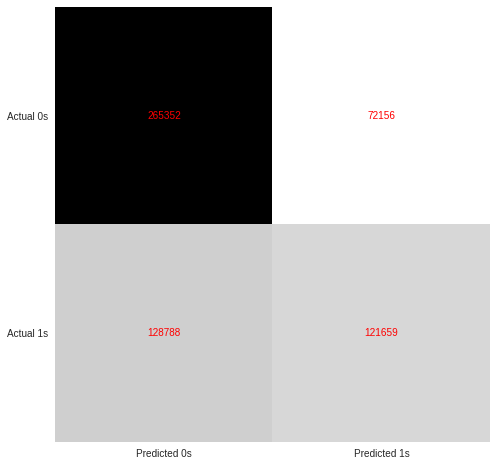

time: 764 ms (started: 2021-01-09 12:50:10 +00:00)


In [ ]:
cm = confusion_matrix(y_test, logreg.predict(test_scaled))

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(cm)
ax.grid(False)
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

time: 927 µs (started: 2021-01-09 12:51:34 +00:00)


In [ ]:
print(classification_report(y_test, logreg.predict(test_scaled)))

              precision    recall  f1-score   support

         0.0       0.67      0.79      0.73    337508
         1.0       0.63      0.49      0.55    250447

    accuracy                           0.66    587955
   macro avg       0.65      0.64      0.64    587955
weighted avg       0.65      0.66      0.65    587955

time: 1.89 s (started: 2021-01-09 12:52:52 +00:00)


In [ ]:
y_test=y_test.reset_index()

time: 41.1 ms (started: 2021-01-09 13:28:14 +00:00)


In [ ]:
y_test = y_test['dead']

time: 1.31 ms (started: 2021-01-09 13:29:06 +00:00)


In [ ]:
y_test

0         1.0
1         0.0
2         1.0
3         0.0
4         1.0
         ... 
587950    0.0
587951    0.0
587952    0.0
587953    0.0
587954    0.0
Name: dead, Length: 587955, dtype: float64

time: 9.97 ms (started: 2021-01-09 13:29:17 +00:00)


In [ ]:
def generate_X():
    while True:
      for j in range(3000,2848958):
        X=[]
        X.append(train_scaled[j-3000:j,:])
        X = np.array(X)
        yield X


def generate_y():
    while True:
        for j in range(3000, 2848958):
          Y=[]
          Y.append(y_test[j-3000:j])
          Y = np.array(Y)
          yield Y

def batch_generator(batch_size, gen_x,gen_y):

    batch_features = np.zeros((batch_size,3000, 4))
    batch_labels = np.zeros((batch_size,3000))

    while True:
        for i in range(batch_size):
            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
        yield batch_features, batch_labels

#logreg.fit_generator(batch_generator(300, generate_X(), generate_y()),
 #                   steps_per_epoch=(len(train_scaled)/300), epochs=2, verbose=1)

time: 13.6 ms (started: 2021-01-09 13:32:09 +00:00)


In [ ]:
s = next(generate_X())
len(s[0])

3000

time: 3.8 ms (started: 2021-01-09 13:34:59 +00:00)


In [ ]:
s = next(generate_y())
len(s[0])

3000

time: 6.4 ms (started: 2021-01-09 13:35:12 +00:00)


In [ ]:
y_test[0]

1.0

time: 2.7 ms (started: 2021-01-09 13:32:11 +00:00)


In [ ]:
next(generate_y())

array([[1., 0., 1., ..., 0., 0., 1.]])

time: 3.36 ms (started: 2021-01-09 13:32:12 +00:00)


In [ ]:
from keras.layers import Flatten,Dense, Activation
from keras.models import Sequential
model = Sequential()
#model.add(Flatten(input_shape=(300,12000, 4)))
#model.add(Dense(12))
model.add(Activation('softmax'))
model.compile(loss='categorical_crossentropy',optimizer='sgd', metrics = ['acc'])
model.fit_generator(batch_generator(300, generate_X(), generate_y()),
                     epochs=2, verbose=1)

/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/engine/training.py:1844: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/2


ValueError: ignored

time: 236 ms (started: 2021-01-09 13:36:53 +00:00)


5. b. Learning Curve plot of Logisitic Regression Model

In [ ]:
train_sizes = [1, 100, 500, 2000, 5000, 7654]

time: 1.05 ms (started: 2021-01-09 12:38:44 +00:00)


In [ ]:
train_sizes, train_scores, validation_scores = learning_curve(
estimator = LogisticRegression(),
X = X_train,
y = y_train, train_sizes = train_sizes, cv = 5,
scoring = 'neg_mean_squared_error')

/usr/local/lib/python3.6/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0.0

  FitFailedWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0.0

  FitFailedWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: This solver needs samples of at least 2 classes in the data, but the data con

time: 12 s (started: 2021-01-09 12:38:50 +00:00)


In [ ]:
train_scores_mean = -train_scores.mean(axis = 1)
validation_scores_mean = -validation_scores.mean(axis = 1)

time: 1.25 ms (started: 2021-01-09 12:39:21 +00:00)


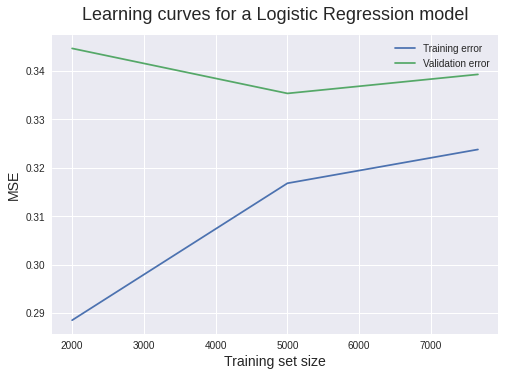

time: 278 ms (started: 2021-01-09 12:39:22 +00:00)


In [ ]:
plt.style.use('seaborn')
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('MSE', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves for a Logistic Regression model', fontsize = 18, y = 1.03)
plt.legend()
#plt.ylim(100,100)

LSTM